In [1]:
# Uncomment these in a fresh notebook environment.
#%pip install -r ../requirements.txt
#%pip install -e ..

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt

GREEN_PHASE_COUNT = 4

def print_comparison_table(rows):
    columns = [
        "Policy",
        "Episodes",
        "Mean total reward",
        "Mean local queue",
        "Total completed steps",
        "Mean switches / episode",
    ]

    def format_value(value):
        if isinstance(value, float):
            return f"{value:.3f}"
        return str(value)

    widths = {column: len(column) for column in columns}
    for row in rows:
        for column in columns:
            widths[column] = max(widths[column], len(format_value(row.get(column, ""))))

    header = " | ".join(column.ljust(widths[column]) for column in columns)
    separator = "-+-".join("-" * widths[column] for column in columns)
    print(header)
    print(separator)
    for row in rows:
        print(" | ".join(format_value(row.get(column, "")).ljust(widths[column]) for column in columns))


In [3]:
from marl_tsc.simulation_generator import SimulationGenerator, DEFAULT_TRAFFIC_LIGHT_IDS
from marl_tsc.training import train_ppo, evaluate_policy, plot_training_histories
from marl_tsc.mappo import train_mappo
from marl_tsc.baselines import random_actions, fixed_time_actions


## 1. Generate the SUMO simulation files

This default setup is a small `4x4` grid with four traffic-light agents. Change these values first when you want a different learning problem.


In [25]:
# ==========================================
# MASTER VARIABLE: Controls the entire run
# ==========================================
EPISODE_STEPS = 100_000  # The number of actions/steps the RL agent takes per episode


# ==========================================
# Derived Parameters
# ==========================================
SECONDS_PER_ACTION = 5  # Matches the step logic in your SumoTrafficEnv
# The actual duration in SUMO seconds that the RL agent will experience
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION  # 3000 SUMO seconds

# To ensure continuous flow, spawn vehicles for 20% longer than the simulation runs.
# This guarantees that the network never empties out or hits ACT = 0.
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)  # 3600 SUMO seconds

NUM_EPISODES = 30
TOTAL_TIMESTEPS = SIMULATION_DURATION
MIN_GREEN_SECONDS = 10


# ==========================================
# Generator Configuration
# ==========================================
generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    grid_number=4,
    lane_number=2,
    traffic_light_ids=traffic_light_ids,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,  # Extends past the simulation end!
    trip_period=2,                    # Steady stream: 1 car every 2 seconds
    seed=42,
)

paths = generator.generate_all()
print(f"Generated continuous flow configuration: {paths.config_file}")
print(f"Simulation Horizon: {SIMULATION_DURATION}s | Traffic Spawning Until: {TRAFFIC_SPAWN_DURATION}s")
print("Traffic-light agents:", traffic_light_ids)


Success.
calling /usr/share/sumo/bin/duarouter -n /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/network.net.xml -r /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/trips.trips.xml --ignore-errors --begin 0 --end 600000 --no-step-log --no-warnings -o /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/routes.rou.xml
Success.
Generated continuous flow configuration: /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/config.sumocfg
Simulation Horizon: 500000s | Traffic Spawning Until: 600000s
Traffic-light agents: ['B1', 'B2', 'C1', 'C2']


## 2. Run the simple baselines

Random and fixed-time are useful sanity checks before training. They use the same environment and the same evaluation seeds as the learned policies.


In [59]:
# ==========================================
# 1. RANDOM BASELINE EVALUATION
# ==========================================
random_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,             # Match MAPPO: TODO:Extract dynamically from the net file
    policy=random_actions,
    episodes=10,#EVALUATION_EPISODES,       # Use 10 episodes to match MAPPO evaluation
    max_steps=600, #EPISODE_STEPS,            # FIX: Must be 600 steps, not 3000 duration
    seed=42,
    env_kwargs={
        "green_phase_count": 4,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        #"max_steps": 600,     # Pass to ensure internal alignment
    },
)

# ==========================================
# 2. FIXED-TIME BASELINE EVALUATION
# ==========================================
fixed_time_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,             # Match MAPPO: TODO: Extract dynamically from the net file
    policy=fixed_time_actions,
    episodes= 10,#EVALUATION_EPISODES,       # Use 10 episodes to match MAPPO evaluation
    max_steps= 600, #EPISODE_STEPS,            # FIX: Must be 600 steps, not 3000 duration
    seed=42,
    env_kwargs={
        "green_phase_count": 4,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        #"max_steps": 600,     # Pass to ensure internal alignment
    },
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #3000.00 (1ms ~= 1000.00*RT, ~41000.00UPS, TraCI: 8ms, vehicles TOT 1500 ACT 41 BUF 0
Finished Evaluation Episode 1/10 - Total Reward: -135.78
 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 1ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #3000.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 1500 ACT 38 BUF 0)                
Finished Evaluation Episode 2/10 - Total Reward: -134.53
 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #3000.00 (0ms ?*RT. ?UPS, TraCI: 6ms, vehicles TOT 1500 ACT 36 BUF 0)                
Finished Evaluation Episode 3/10 - Total Reward: -133.00
 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #3000.0

In [58]:
print_comparison_table(baseline_rows)

Policy     | Episodes | Mean total reward | Mean local queue | Total completed steps | Mean switches / episode
-----------+----------+-------------------+------------------+-----------------------+------------------------
Random     | 30       | -135.096          | 0.492            | 18944                 | 1077.267               
Fixed time | 30       | -5482.823         | 4.519            | 90000                 | 5996.000               


## 3. Train

PPO uses parameter sharing through the PettingZoo/SuperSuit/SB3 wrapper. MAPPO adds a centralized critic and a shared decentralized actor.


### PPO

In [ ]:
ppo_model, ppo_history, ppo_model_path = train_ppo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    max_steps=SIMULATION_DURATION,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": MIN_GREEN_SECONDS },
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 1ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 9ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #600075.00 (0ms ?*RT. ?UPS, TraCI: 4ms, vehicles TOT 300000 ACT 0 BUF 0)             tep #4500.00 (1ms ~= 1000.00*RT, ~36000.00UPS, TraCI: 11ms, vehicles TOT 2251 ACT 36 BUF ep #9000.00 (1ms ~= 1000.00*RT, ~40000.00UPS, TraCI: 9ms, vehicles TOT 4500 ACT 40 BUF 1p #13500.00 (0ms ?*RT. ?UPS, TraCI: 10ms, vehicles TOT 6751 ACT 33 BUF 0)               #18000.00 (0ms ?*RT. ?UPS, TraCI: 9ms, vehicles TOT 9001 ACT 35 BUF 0)               #22500.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 11250 ACT 32 BUF 1)              27000.00 (1ms ~= 1000.00*RT, ~42000.00UPS, TraCI: 9ms, vehicles TOT 13500 ACT 42 BUF1500.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 15751 ACT 46 BUF 0)              000.00 (1ms ~= 1000.00*RT, ~37000.00UPS, TraCI: 8ms, vehicl

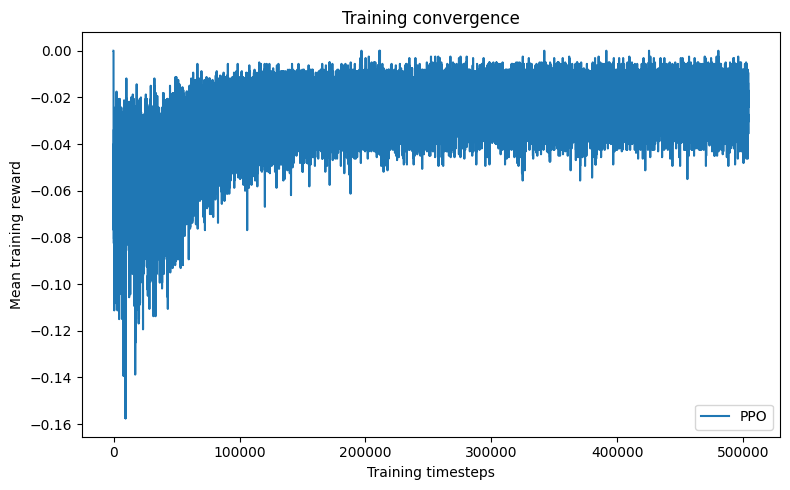

Saved PPO model: /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/ppo_sumo_traffic.zip


In [ ]:

fig, ax = plot_training_histories(ppo_history)
plt.show()

print("Saved PPO model:", ppo_model_path)

### MAPPO

In [ ]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=1024,
    max_steps=SIMULATION_DURATION,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": MIN_GREEN_SECONDS },
)

fig, ax = plot_training_histories(mappo_history)
plt.show()

print("Saved MAPPO model:", mappo_model_path)

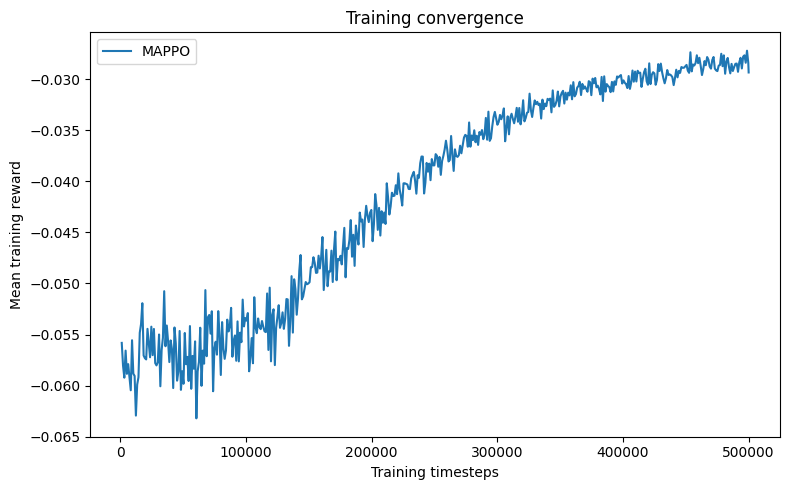

In [70]:
fig, ax = plot_training_histories(mappo_history)
plt.show()

## 4. Evaluate all policies on the same seeds

The final comparison table keeps the baseline runs and adds the shared PPO and MAPPO policies on the same evaluation seeds.


In [28]:
shared_mappo_result = evaluate_policy(
    config_file=paths.config_file,
    # 1. Pass None to dynamically extract the agents from the network file, matching training!
    traffic_light_ids=traffic_light_ids, 
    policy=mappo_model,
    episodes=EVALUATION_EPISODES,
    # 2. FIX: Must be EPISODE_STEPS, not SIMULATION_DURATION
    max_steps=EPISODE_STEPS, 
    seed=42, 
    # 3. Pass every environment hyperparameter to ensure observation spaces align perfectly
    env_kwargs={
        "green_phase_count": 4,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        #"max_steps": EPISODE_STEPS,
    },
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 1ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #500000.00 (1ms ~= 1000.00*RT, ~25000.00UPS, TraCI: 8ms, vehicles TOT 250000 ACT 25 Btep #4500.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 2251 ACT 26 BUF 0)                ep #9000.00 (0ms ?*RT. ?UPS, TraCI: 10ms, vehicles TOT 4500 ACT 27 BUF 1)               p #13500.00 (1ms ~= 1000.00*RT, ~32000.00UPS, TraCI: 8ms, vehicles TOT 6751 ACT 32 BUF  #18000.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 9001 ACT 30 BUF 0)               #22500.00 (1ms ~= 1000.00*RT, ~21000.00UPS, TraCI: 8ms, vehicles TOT 11250 ACT 21 BUF27000.00 (1ms ~= 1000.00*RT, ~27000.00UPS, TraCI: 9ms, vehicles TOT 13500 ACT 27 BUF1500.00 (0ms ?*RT. ?UPS, TraCI: 9ms, vehicles TOT 15751 ACT 33 BUF 0)              000.00 (0ms ?*RT. ?UPS, TraCI: 11ms, vehicles TOT 18001 ACT 22 BUF 0)             00.00 (1ms ~= 1000.00*RT, ~32000.00UPS, TraCI: 14ms, vehicles TOT 20250 ACT 32 BU0.00 (1ms

In [ ]:
shared_ppo_result = evaluate_policy(
    config_file=paths.config_file,
    # 1. Pass None to dynamically extract the agents from the network file, matching training!
    traffic_light_ids=traffic_light_ids, 
    policy=ppo_model,
    episodes=EVALUATION_EPISODES,
    # 2. FIX: Must be EPISODE_STEPS, not SIMULATION_DURATION
    max_steps=EPISODE_STEPS, 
    seed=42, 
    # 3. Pass every environment hyperparameter to ensure observation spaces align perfectly
    env_kwargs={
        "green_phase_count": 4,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        #"max_steps": EPISODE_STEPS,
    },
)

In [71]:
'''comparison_rows = baseline_rows + [
    {
        "Policy": "Shared PPO",
        "Episodes": shared_ppo_result["episodes"],
        "Mean total reward": shared_ppo_result["mean_total_reward"],
        "Mean local queue": shared_ppo_result["mean_local_queue"],
        "Total completed steps": shared_ppo_result["total_completed_steps"],
        "Mean switches / episode": shared_ppo_result["mean_switches_per_episode"],
    },'''
comparison_rows = baseline_rows + [
        {
        "Policy": "MAPPO",
        "Episodes": shared_mappo_result["episodes"],
        "Mean total reward": shared_mappo_result["mean_total_reward"],
        "Mean local queue": shared_mappo_result["mean_local_queue"],
        "Total completed steps": shared_mappo_result["total_completed_steps"],
        "Mean switches / episode": shared_mappo_result["mean_switches_per_episode"],
    },
]

print_comparison_table(comparison_rows)


Policy     | Episodes | Mean total reward | Mean local queue | Total completed steps | Mean switches / episode
-----------+----------+-------------------+------------------+-----------------------+------------------------
Random     | 30       | -135.096          | 0.492            | 18944                 | 1077.267               
Fixed time | 30       | -5482.823         | 4.519            | 90000                 | 5996.000               
MAPPO      | 10       | -9192.593         | 0.184            | 1000000               | 181541.400             


## 5. Performance Analysis (100-Episode Moving Average) - NEEDS REVISION

This section visualizes the training progress by smoothing the rewards. It prioritizes the `moving_avg_episode_return` (available in MAPPO) and falls back to smoothing the `mean_training_reward` for PPO.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_moving_average_analysis(histories, window=100):
    if not histories:
        print("No history data found.")
        return

    df = pd.DataFrame(histories)
    fig, ax = plt.subplots(figsize=(12, 6))

    for algorithm in df['algorithm'].unique():
        algo_df = df[df['algorithm'] == algorithm].sort_values('timestep')
        
        # Identify the best metric to plot
        # MAPPO logs 'moving_avg_episode_return'; PPO logs 'mean_training_reward'
        metric = "moving_avg_episode_return" if "moving_avg_episode_return" in algo_df.columns else "mean_training_reward"
        
        # Calculate moving average (min_periods=1 allows plotting to start immediately)
        algo_df['smoothed'] = algo_df[metric].rolling(window=window, min_periods=1).mean()
        
        label_suffix = " (Episode Return)" if metric == "moving_avg_episode_return" else " (Step Reward)"
        line, = ax.plot(
            algo_df['timestep'], 
            algo_df['smoothed'], 
            label=f"{algorithm.upper()}{label_suffix}", 
            linewidth=2
        )
        
        # Plot raw data with high transparency to show variance/noise
        ax.plot(algo_df['timestep'], algo_df[metric], alpha=0.15, color=line.get_color())

    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Reward Value")
    ax.set_title(f"Training Performance: {window}-pt Moving Average")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Combine histories from both training runs and plot
combined_history =  mappo_history
plot_moving_average_analysis(combined_history, window=100)

### Traci Escape Hatch

In [67]:
# Stop Traci processes if not already stopped, to prevent connection issues in subsequent runs
import sys

# 1. Force clear TraCI's internal connection registries
try:
    import traci
    traci.switch("default")
    traci.close()
except Exception:
    pass

try:
    # Completely purge the connection dictionary tracking connections
    import traci.main
    traci.main._connections.clear()
    print("Purged TraCI connections dictionary.")
except Exception:
    pass

# 2. Reset the module completely out of Python sys memory
if 'traci' in sys.modules:
    del sys.modules['traci']
    print("Flushed TraCI module from Python runtime memory.")

# 3. Re-import fresh
import traci
print("TraCI state successfully reset!")

Flushed TraCI module from Python runtime memory.
TraCI state successfully reset!
